c:\Users\AMD\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]
(395, 33)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,593 (57.00 KB)

 Trainable params: 14,593 (57.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - loss: 108.6886 - mae: 9.4897 - val_loss: 79.3515 - val_mae: 8.2785
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 67.2083 - mae: 7.2478 - val_loss: 25.2519 - val_mae: 4.2202
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 23.5290 - mae: 3.9723 - val_loss: 15.7025 - val_mae: 2.6932
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 15.3241 - mae: 2.9365 - val_loss: 10.2300 - val_mae: 2.3956
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 11.0694 - mae: 2.7153 - val_loss: 8.4960 - val_mae: 2.1449
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 8.3443 - mae: 2.2693 - val_loss: 7.7012 - val_mae: 2.1006
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 9.4056 - mae: 2.3615 - val_loss: 7.2629 - val_mae: 2.0313
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 6.7133 - mae: 2.0797 - val_loss: 7.5295 - val_mae: 2.1430
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms

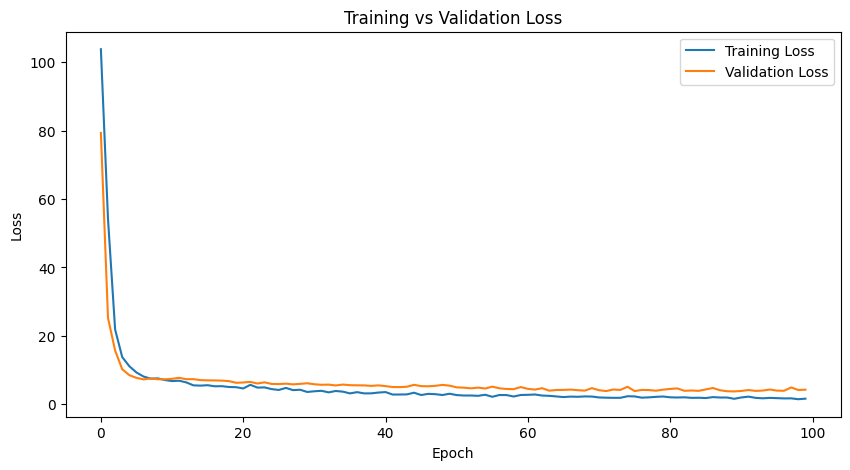

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

# ==========================
# Load Dataset
# ==========================

df = pd.read_csv("student-mat.csv", sep=';')

print(df.head())
print(df.shape)

# ==========================
# Encode Categorical Columns
# ==========================

label_encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = label_encoder.fit_transform(df[column])

# ==========================
# Features and Target
# ==========================

X = df.drop("G3", axis=1)
y = df["G3"]

# ==========================
# Feature Scaling
# ==========================

scaler = StandardScaler()

X = scaler.fit_transform(X)

# ==========================
# Train-Test Split
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================
# Build MLP Model
# ==========================

model = Sequential([
    Input(shape=(X_train.shape[1],)),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(32, activation='relu'),

    Dense(1)
])

# ==========================
# Compile Model
# ==========================

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# ==========================
# Model Summary
# ==========================

model.summary()

# ==========================
# Train Model
# ==========================

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=1
)

# ==========================
# Evaluate Model
# ==========================

loss, mae = model.evaluate(X_test, y_test)

print("\nTest Loss:", loss)
print("Test MAE:", mae)

# ==========================
# Predictions
# ==========================

predictions = model.predict(X_test)

print("\nActual Grade -> Predicted Grade")

for i in range(10):
    print(
        f"{y_test.iloc[i]} -> {predictions[i][0]:.2f}"
    )

# ==========================
# Plot Training History
# ==========================

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()